# 백테스트 리포트 (20종목 × 5%, Buy & Hold)
데이터: `데이터.xlsx` (같은 폴더). 위에서부터 순서대로 실행하세요.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.table import Table
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
%matplotlib inline

## 1. 스타일

In [2]:
def _apply_date_axis(ax):
    locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))


COLOR_MAIN = "#161C3C"
COLOR_TEXT = "#111111"
COLOR_EMPH1 = "#C05621"
COLOR_EMPH2 = "#C9A227"
COLOR_EMPH3 = "#4DA3FF"
COLOR_GRID = "#E5E5E5"
COLOR_ROW_ALT = "#F4F5F8"
FONT_FAMILY = ["Calibri", "Arial", "DejaVu Sans"]
PALETTE = [COLOR_MAIN, COLOR_EMPH3, COLOR_EMPH1, COLOR_EMPH2]


def apply_theme():
    plt.rcParams.update({
        "font.family": FONT_FAMILY, "text.color": COLOR_TEXT,
        "axes.labelcolor": COLOR_TEXT, "axes.edgecolor": COLOR_TEXT,
        "axes.titlecolor": COLOR_MAIN, "axes.titleweight": "bold", "axes.titlesize": 13,
        "xtick.color": COLOR_TEXT, "ytick.color": COLOR_TEXT,
        "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.grid": True, "grid.color": COLOR_GRID, "grid.linewidth": 0.6,
        "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 9, "font.size": 10,
    })


def plot_equity_curve(ax, dates, series_dict, title="Equity Curve"):
    for i, (name, values) in enumerate(series_dict.items()):
        ax.plot(dates, values, label=name, color=PALETTE[i % len(PALETTE)], linewidth=1.8)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    _apply_date_axis(ax)
    if len(series_dict) > 1:
        ax.legend(loc="upper left")
    ax.margins(x=0.01)
    return ax


def plot_drawdown(ax, dates, drawdown_pct, title="Drawdown"):
    ax.fill_between(dates, drawdown_pct, 0, color=COLOR_EMPH1, alpha=0.35, linewidth=0)
    ax.plot(dates, drawdown_pct, color=COLOR_EMPH1, linewidth=1.2)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    _apply_date_axis(ax)
    ax.margins(x=0.01)
    return ax


def plot_bar(ax, labels, values, title="", highlight_sign=True):
    colors = [COLOR_EMPH3 if v >= 0 else COLOR_EMPH1 for v in values] if highlight_sign else COLOR_MAIN
    ax.bar(labels, values, color=colors, width=0.7)
    ax.axhline(0, color=COLOR_TEXT, linewidth=0.8)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    return ax


def render_table(ax, df, title=None, col_widths=None):
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left", pad=12)
    n_rows, n_cols = df.shape
    tbl = Table(ax, bbox=[0, 0, 1, 1])
    if col_widths is None:
        col_widths = [1.0 / n_cols] * n_cols
    row_height = 1.0 / (n_rows + 1)
    for j, col_name in enumerate(df.columns):
        cell = tbl.add_cell(0, j, col_widths[j], row_height, text=str(col_name), loc="center", facecolor=COLOR_MAIN)
        cell.get_text().set_color("white"); cell.get_text().set_fontweight("bold")
    for i in range(n_rows):
        row_color = COLOR_ROW_ALT if i % 2 == 0 else "white"
        for j in range(n_cols):
            cell = tbl.add_cell(i + 1, j, col_widths[j], row_height, text=str(df.iloc[i, j]), loc="center", facecolor=row_color)
            cell.get_text().set_color(COLOR_TEXT)
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    ax.add_table(tbl)
    return tbl

apply_theme()

## 2. 설정 & 데이터

In [3]:
DATA_PATH    = "데이터.xlsx"            # 노트북과 같은 폴더
START, END   = "2021-08-17", "2023-08-31"   # 2Q 공시 이후 매수(미래정보 방지). 8/2부터 하려면 "2021-08-02"
INIT_CAPITAL = 100_000_000
COST_BUY, COST_SELL = 0.00015, 0.00015 + 0.0020   # 매수 수수료 / 매도 수수료+거래세(대략치)

In [4]:
def load_prices(path):
    raw = pd.read_excel(path, header=None)
    dates = pd.to_datetime(raw.iloc[0, 6:].values)
    body = raw.iloc[1:].copy()
    px = pd.DataFrame(body.iloc[:, 6:].astype(float).values.T, index=dates, columns=body[0].values)
    names = dict(zip(body[0], body[1]))
    return px.sort_index(), names

prices, names = load_prices(DATA_PATH)
BENCH = "I.101"                                   # 코스피 200
stock_cols = [c for c in prices.columns if c != BENCH]
prices = prices.loc[START:END]
print(f"종목 수: {len(stock_cols)}  |  기간: {prices.index[0]:%Y-%m-%d} ~ {prices.index[-1]:%Y-%m-%d}")
pd.Series({c: names[c] for c in stock_cols}, name="종목명").to_frame()

종목 수: 20  |  기간: 2021-08-17 ~ 2023-08-31


,종목명
A003240,태광산업
A049070,인탑스
A004970,신라교역
A058650,세아홀딩스
A002170,SYTS
A009970,영원무역홀딩스
A003030,세아제강지주
A034220,LG디스플레이
A013570,디와이
A002920,유성기업


## 3. 백테스트

In [5]:
def run_backtest(px, cols):
    stocks = px[cols].ffill()
    w = 1.0 / len(cols)                               # 종목당 5%
    rel = stocks / stocks.iloc[0]                     # 첫날 종가 매수 (Buy & Hold)
    pos_val = rel * (INIT_CAPITAL * w) * (1 - COST_BUY)
    equity = pos_val.sum(axis=1)
    equity.iloc[-1] -= pos_val.iloc[-1].sum() * COST_SELL   # 마지막 날 청산 비용
    return equity, pos_val

def perf_stats(eq):
    r = eq.pct_change().dropna()
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    total = eq.iloc[-1] / eq.iloc[0] - 1
    cagr = (1 + total) ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(252)
    dd = eq / eq.cummax() - 1
    return {"Total Return": f"{total:.1%}", "CAGR": f"{cagr:.1%}", "Volatility": f"{vol:.1%}",
            "Sharpe (rf=0)": f"{(r.mean() * 252) / vol:.2f}", "Max Drawdown": f"{dd.min():.1%}",
            "Win Rate (daily)": f"{(r > 0).mean():.1%}"}

equity, pos_val = run_backtest(prices, stock_cols)
pd.Series(perf_stats(equity), name="Strategy").to_frame()

,Strategy
Total Return,2.6%
CAGR,1.3%
Volatility,20.1%
Sharpe (rf=0),0.16
Max Drawdown,-24.6%
Win Rate (daily),56.3%


## 4. 리포트

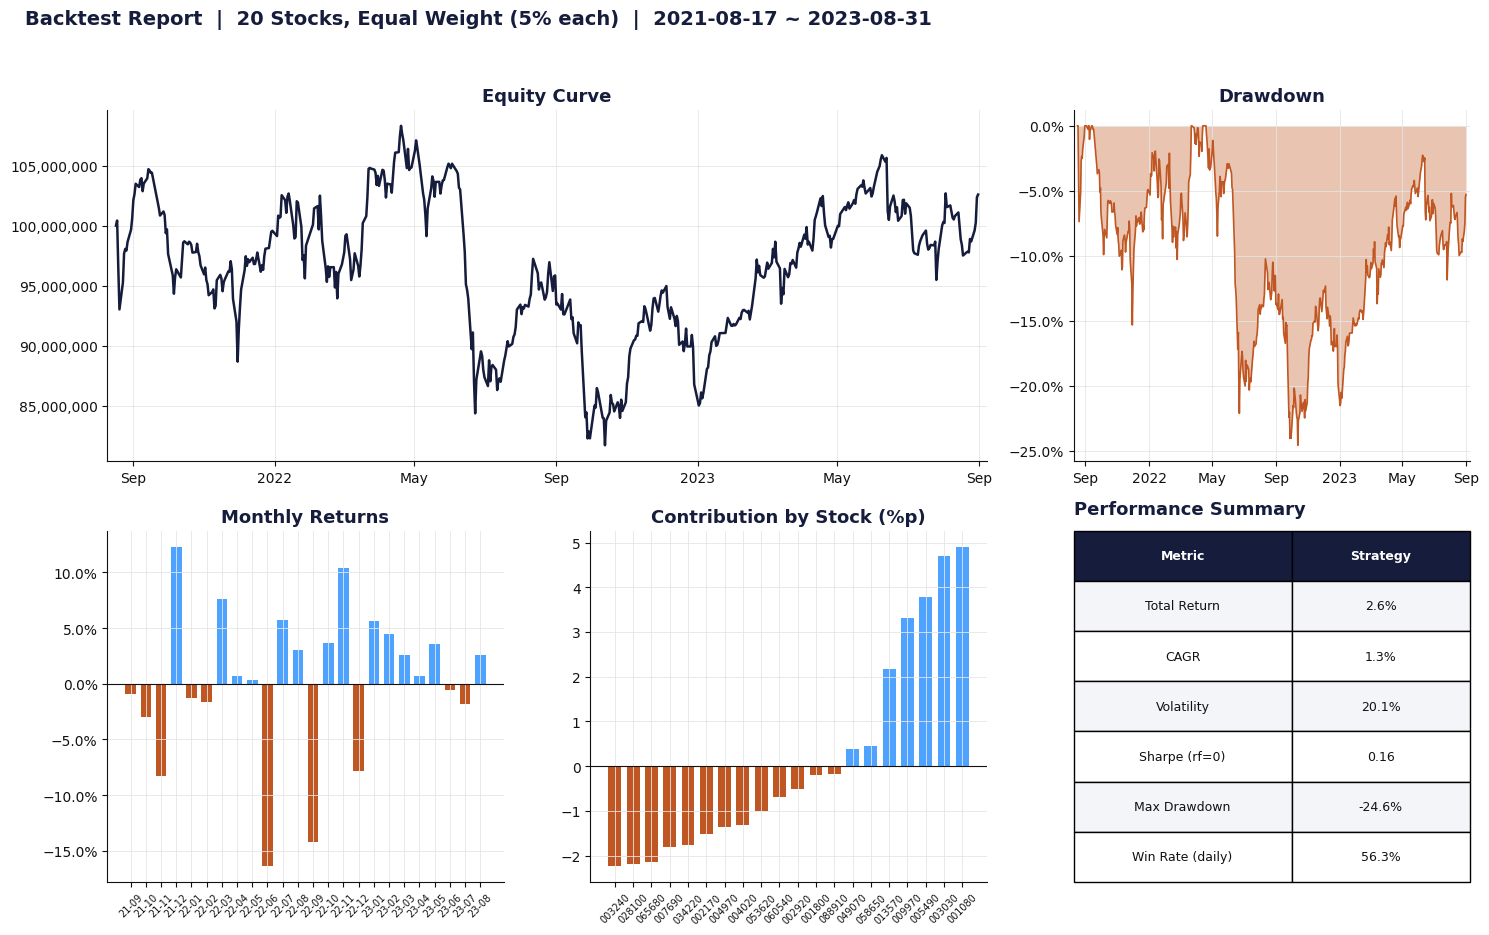

In [6]:
dd = equity / equity.cummax() - 1
monthly = equity.resample("ME").last().pct_change().dropna()
m_labels = [d.strftime("%y-%m") for d in monthly.index]
contrib = ((pos_val.iloc[-1] - pos_val.iloc[0]) / INIT_CAPITAL * 100).sort_values()
s = perf_stats(equity)
summary = pd.DataFrame({"Metric": list(s.keys()), "Strategy": list(s.values())})

fig = plt.figure(figsize=(15, 9.5))
gs = fig.add_gridspec(2, 3)
fig.suptitle(f"Backtest Report  |  {len(stock_cols)} Stocks, Equal Weight (5% each)  |  {equity.index[0]:%Y-%m-%d} ~ {equity.index[-1]:%Y-%m-%d}",
             fontsize=14, fontweight="bold", color=COLOR_MAIN, x=0.02, ha="left")
ax1 = fig.add_subplot(gs[0, 0:2]); plot_equity_curve(ax1, equity.index, {"Strategy": equity})
ax2 = fig.add_subplot(gs[0, 2]);   plot_drawdown(ax2, dd.index, dd)
ax3 = fig.add_subplot(gs[1, 0]);   plot_bar(ax3, m_labels, monthly.values, title="Monthly Returns")
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0)); ax3.tick_params(axis="x", labelsize=7)
ax4 = fig.add_subplot(gs[1, 1]);   plot_bar(ax4, [c.replace("A", "") for c in contrib.index], contrib.values, title="Contribution by Stock (%p)")
ax4.tick_params(axis="x", labelsize=7)
ax5 = fig.add_subplot(gs[1, 2]);   render_table(ax5, summary, title="Performance Summary", col_widths=[0.55, 0.45])
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("backtest_report.png", dpi=200)
plt.show()